# Relapse-Driven Bistability in a Model of Gang Dynamics
## 3. PRCC sensitivity analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/machyman/kwofie2026relapse/blob/main/notebooks/03_prcc_sensitivity.ipynb)

Reproduces Figure 8 and Table 4 of the companion paper (MBE-8616).

**The response variable matters.** The model is bistable, so a sensitivity measure based
on simulating to steady state from a fixed initial condition would confound two different
things: how parameters move the *equilibrium level*, and how they move the *basin
boundary*. We therefore evaluate the response at the high-prevalence equilibrium $E_+$
directly, which makes it independent of the initial condition.

Advocacy $\eta$ has baseline zero, so a $\pm 20\%$ range would be degenerate; it is
sampled over $[0, 1]$ instead.

This notebook also writes `data/prcc_lhs_samples.csv`, the shared Latin Hypercube design
used to obtain **exact** cross-language agreement with the MATLAB implementation (seeded
random streams differ between languages, so the design must be shared rather than
regenerated).

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
"""
PRCC sensitivity of long-term gang prevalence (Figure 8, Table 4).

Author:  James M. Hyman
         Department of Mathematics, Tulane University
         mhyman@tulane.edu
Date:    2026-07-04  Version 1.0
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings, os, sys, json

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
RNG  = np.random.default_rng(SEED)
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size'      : 12,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 11,
    'figure.dpi'     : 120,
    'lines.linewidth': 1.8,
})

# ── Scale switch ──────────────────────────────────────────────────────────────
# FULL = False  →  quick verification run (well under 5 minutes)
# FULL = True   →  publication-quality run (matches the figures in the paper)
FULL = False
SCALE = dict(n_samples = 1000, n_boot = 1000 if FULL else 200)
print(f"Scale: {'FULL (publication)' if FULL else 'QUICK (verification)'}")
print(f"Parameters: {SCALE}")

# ── Repository root (works in Colab and locally) ───────────────────────────────
if not os.path.exists('python'):
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    elif not os.path.exists('kwofie2026relapse'):
        !git clone -q https://github.com/machyman/kwofie2026relapse.git
        os.chdir('kwofie2026relapse')
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

# ── The engine (generated by notebook 01; the single definition of the model) ──
sys.path.insert(0, 'python')
from sgr_engine import (Params, ILLUSTRATIVE, replace, equilibria, classify,
                        rhs, jacobian, r0_simp, gstar)
print(f"Working directory: {os.getcwd()}")
print(f"Engine loaded. Baseline R0_simp = {r0_simp(ILLUSTRATIVE):.4f}")

Scale: QUICK (verification)
Parameters: {'n_samples': 1000, 'n_boot': 200}
Working directory: /mnt/user-data/outputs/kwofie2026relapse
Engine loaded. Baseline R0_simp = 0.9884


## Implementation

Latin Hypercube sampling, the rank transformation, the partial rank correlation, and the
bootstrap are written out explicitly rather than called from a library, so that the
MATLAB port can mirror them exactly (MATLAB's equivalents live in the Statistics
Toolbox, which not every reader has).

In [2]:
from scipy.stats import qmc, rankdata

PARAM_ORDER = ['beta_sg', 'gamma', 'beta_rg', 'beta_rs', 'eps', 'eta']
PARAM_TEX = {'beta_sg': r'$\beta_{sg}$', 'gamma': r'$\gamma$', 'beta_rg': r'$\beta_{rg}$',
             'beta_rs': r'$\beta_{rs}$', 'eps': r'$\epsilon$', 'eta': r'$\eta$'}
BASE = replace(ILLUSTRATIVE, beta_sg=0.855)
FRAC, RANGE_ETA = 0.20, (0.0, 1.0)


def bounds():
    """Sampling bounds: +/-20% of baseline, except eta (baseline 0) over [0, 1]."""
    b = {}
    for name in PARAM_ORDER:
        if name == 'eta':
            b[name] = RANGE_ETA
        else:
            v = getattr(BASE, name)
            b[name] = ((1 - FRAC) * v, (1 + FRAC) * v)
    return b


def sample_lhs(n, seed=SEED):
    bd = bounds()
    lo = np.array([bd[k][0] for k in PARAM_ORDER])
    hi = np.array([bd[k][1] for k in PARAM_ORDER])
    unit = qmc.LatinHypercube(d=len(PARAM_ORDER), seed=seed).random(n)
    return qmc.scale(unit, lo, hi)


def responses(X):
    """g* at the high-prevalence equilibrium E_+ (initial-condition independent)."""
    return np.array([gstar(replace(BASE, **dict(zip(PARAM_ORDER, row)))) for row in X])


def partial_rank_corr(X, y):
    """PRCC of each column of X with y, controlling for the other columns."""
    n, k = X.shape
    Rx = np.column_stack([rankdata(X[:, j]) for j in range(k)]).astype(float)
    Ry = rankdata(y).astype(float)
    out = np.zeros(k)
    for i in range(k):
        others = [j for j in range(k) if j != i]
        Z = np.column_stack([np.ones(n)] + [Rx[:, j] for j in others])
        rx = Rx[:, i] - Z @ np.linalg.lstsq(Z, Rx[:, i], rcond=None)[0]
        ry = Ry - Z @ np.linalg.lstsq(Z, Ry, rcond=None)[0]
        sx, sy = rx.std(), ry.std()
        out[i] = float(np.mean(rx * ry) / (sx * sy)) if sx > 1e-12 and sy > 1e-12 else 0.0
    return out


def bootstrap_ci(X, y, n_boot, seed=SEED):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    boot = np.array([partial_rank_corr(X[i], y[i])
                     for i in (rng.integers(0, n, n) for _ in range(n_boot))])
    return np.percentile(boot, 2.5, axis=0), np.percentile(boot, 97.5, axis=0)


X = sample_lhs(SCALE['n_samples'])
np.savetxt('data/prcc_lhs_samples.csv', X, delimiter=',', fmt='%.17g')
y = responses(X)
prcc = partial_rank_corr(X, y)
lo, hi = bootstrap_ci(X, y, SCALE['n_boot'])

print(f"samples: {X.shape[0]}   bootstrap resamples: {SCALE['n_boot']}")
print(f"fraction of samples with a positive equilibrium: {np.mean(y > 1e-6):.3f}")
print(f"mean g* = {y.mean():.4f}")
print("shared design written to data/prcc_lhs_samples.csv (used for MATLAB parity)")

samples: 1000   bootstrap resamples: 200
fraction of samples with a positive equilibrium: 1.000
mean g* = 0.4498
shared design written to data/prcc_lhs_samples.csv (used for MATLAB parity)


## Mathematical verification suite

The checks assert the values reported in the paper. The point estimates do not depend on
the scale switch (the sample size is fixed at 1000); only the width of the bootstrap
intervals does.

In [3]:
EXPECTED = {'gamma': -0.977, 'beta_rg': +0.976, 'beta_sg': +0.167,
            'eps': -0.059, 'eta': +0.018, 'beta_rs': -0.005}

def verification_suite():
    checks, results = [], []
    def check(name, ok): checks.append(name); results.append(bool(ok))

    pr = dict(zip(PARAM_ORDER, prcc))
    for name, want in EXPECTED.items():
        check(f"PRCC({name}) = {want:+.3f}", abs(pr[name] - want) < 5e-3)
    check("a positive equilibrium exists for every sample", np.mean(y > 1e-6) == 1.0)
    check("gamma and beta_rg are co-dominant and of opposite sign",
          abs(abs(pr['gamma']) - abs(pr['beta_rg'])) < 0.05 and pr['gamma'] * pr['beta_rg'] < 0)
    check("recruitment beta_sg is a smaller positive driver",
          0 < pr['beta_sg'] < 0.5 * abs(pr['gamma']))

    print("PRCC verification"); print("-" * 66)
    for name, ok in zip(checks, results):
        print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
    print("-" * 66)
    print(f"RESULT: {sum(results)}/{len(results)} checks passed.")
    return sum(results), len(results)


N_PASS, N_TOTAL = verification_suite()
assert N_PASS == N_TOTAL, "PRCC verification failed."

PRCC verification
------------------------------------------------------------------
  [PASS]  PRCC(gamma) = -0.977
  [PASS]  PRCC(beta_rg) = +0.976
  [PASS]  PRCC(beta_sg) = +0.167
  [PASS]  PRCC(eps) = -0.059
  [PASS]  PRCC(eta) = +0.018
  [PASS]  PRCC(beta_rs) = -0.005
  [PASS]  a positive equilibrium exists for every sample
  [PASS]  gamma and beta_rg are co-dominant and of opposite sign
  [PASS]  recruitment beta_sg is a smaller positive driver
------------------------------------------------------------------
RESULT: 9/9 checks passed.


## Figure 8 — the sensitivity tornado

Bars are red where increasing the parameter raises long-term gang prevalence and blue
where it lowers it. Error bars are 95% bootstrap percentile intervals; a parameter whose
interval crosses zero has no resolved effect at the equilibrium level.

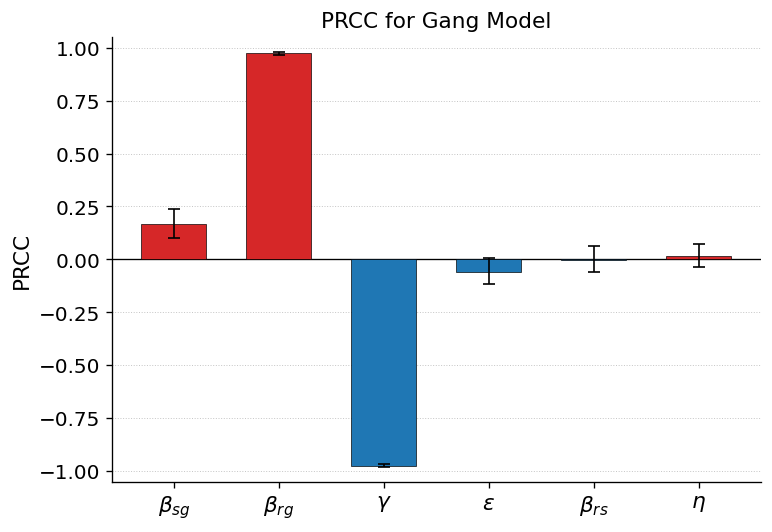

In [4]:
DISPLAY = ['beta_sg', 'beta_rg', 'gamma', 'eps', 'beta_rs', 'eta']
idx = [PARAM_ORDER.index(k) for k in DISPLAY]
vals, los, his = prcc[idx], lo[idx], hi[idx]

fig, ax = plt.subplots(figsize=(6.6, 4.6))
colors = ['#d62728' if v >= 0 else '#1f77b4' for v in vals]
xpos = np.arange(len(DISPLAY))
ax.bar(xpos, vals, color=colors, width=0.62, edgecolor='black', linewidth=0.4, zorder=3)
ax.errorbar(xpos, vals, yerr=[np.abs(vals - los), np.abs(his - vals)], fmt='none',
            ecolor='black', elinewidth=1.0, capsize=3.5, zorder=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels([PARAM_TEX[k] for k in DISPLAY], fontsize=13)
ax.set_ylabel('PRCC'); ax.set_title('PRCC for Gang Model'); ax.set_ylim(-1.05, 1.05)
ax.yaxis.grid(True, ls=':', lw=0.6, alpha=0.7); ax.set_axisbelow(True)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
fig.tight_layout(); fig.savefig('figures/fig08_prcc.png', dpi=150)
plt.show()

## Table 4 — PRCC values with bootstrap confidence intervals

In [5]:
rows = []
print(f"{'parameter':<14}{'PRCC':>9}{'95% CI':>22}   significant")
print("-" * 62)
for k in ['gamma', 'beta_rg', 'beta_sg', 'eps', 'eta', 'beta_rs']:
    j = PARAM_ORDER.index(k)
    sig = not (lo[j] <= 0 <= hi[j])
    print(f"{k:<14}{prcc[j]:+9.3f}   [{lo[j]:+.3f}, {hi[j]:+.3f}]{'':6}{'*' if sig else ''}")
    rows.append(dict(parameter=k, prcc=float(prcc[j]),
                     ci_lo=float(lo[j]), ci_hi=float(hi[j]), significant=bool(sig)))

with open('data/prcc_results.json', 'w') as f:
    json.dump(dict(n_samples=int(X.shape[0]), seed=SEED,
                   n_boot=int(SCALE['n_boot']),
                   response='g* at the high-prevalence equilibrium E_+',
                   frac_positive=float(np.mean(y > 1e-6)),
                   mean_gstar=float(y.mean()), results=rows), f, indent=2)
print("\nwritten: data/prcc_results.json")

parameter          PRCC                95% CI   significant
--------------------------------------------------------------
gamma            -0.977   [-0.981, -0.968]      *
beta_rg          +0.976   [+0.968, +0.981]      *
beta_sg          +0.167   [+0.103, +0.238]      *
eps              -0.059   [-0.116, +0.006]      
eta              +0.018   [-0.036, +0.070]      
beta_rs          -0.005   [-0.058, +0.061]      

written: data/prcc_results.json


## Diagnostic analysis

Why is recruitment only a *small* positive driver here, when it is what sets the invasion
threshold? Because the response is evaluated at the established-gang equilibrium $E_+$,
where susceptibles are nearly depleted ($s \approx 0.02$). Recruitment governs whether a
gang can *invade*; relapse and reformation govern how large it is once *established*.
These are complementary questions, and the PRCC answers the second.

In [6]:
E = equilibria(BASE)
s_plus, g_plus, r_plus = E[-1]
print(f"At the high-gang equilibrium E_+:  s = {s_plus:.4f},  g = {g_plus:.4f},  r = {r_plus:.4f}")
print(f"Susceptibles are depleted to {100*s_plus:.1f}% of the population, so the recruitment")
print("term beta_sg * s * g / D has little room to act. Relapse (beta_rg) and reformation")
print("(gamma) act on the large reformed and gang classes, which is why they dominate.")

At the high-gang equilibrium E_+:  s = 0.0180,  g = 0.4579,  r = 0.5241
Susceptibles are depleted to 1.8% of the population, so the recruitment
term beta_sg * s * g / D has little room to act. Relapse (beta_rg) and reformation
(gamma) act on the large reformed and gang classes, which is why they dominate.


## Summary

- **Reformation $\gamma$ (PRCC $\approx -0.98$) and relapse $\beta_{rg}$ ($\approx +0.98$)
  are co-dominant** drivers of long-term gang prevalence, comparable in magnitude and
  opposite in sign. The established gang is sustained by a relapse-versus-reformation
  balance — the same mechanism that produces the backward bifurcation.
- **Recruitment $\beta_{sg}$ is a smaller positive driver** ($\approx +0.17$), because
  susceptibles are depleted at $E_+$.
- Deterrence, reintegration and advocacy have intervals overlapping zero *at the
  equilibrium level*. Advocacy is nonetheless consequential: it acts at first order on
  the bifurcation **threshold**, which is a different question from equilibrium
  prevalence.
- Policy reading: interventions aimed only at recruitment are unlikely to dislodge an
  established gang. Relapse prevention and exit-pathway support act where the leverage is.

**Revision history:** v1.0 initial release (2026-07).

In [7]:
# ── Download outputs ───────────────────────────────────────────────────────────
output_files = ['figures/fig08_prcc.png', 'data/prcc_results.json',
                'data/prcc_lhs_samples.csv']
try:
    from google.colab import files
    for fname in output_files:
        files.download(fname)
    print("Downloads triggered.")
except ImportError:
    print("Not in Colab — files saved locally:")
    for fname in output_files:
        if os.path.exists(fname):
            print(f"  {fname}  ({os.path.getsize(fname) // 1024} KB)")

Not in Colab — files saved locally:
  figures/fig08_prcc.png  (33 KB)
  data/prcc_results.json  (1 KB)
  data/prcc_lhs_samples.csv  (118 KB)
